<a href="https://colab.research.google.com/github/isaevadaryna/Machine-Learning/blob/main/%D0%9B%D0%B0%D0%B1_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
iris_df = pd.DataFrame(X, columns=iris.feature_names)

print("Перші 5 рядків датасету Iris:")
print(iris_df.head())

Перші 5 рядків датасету Iris:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

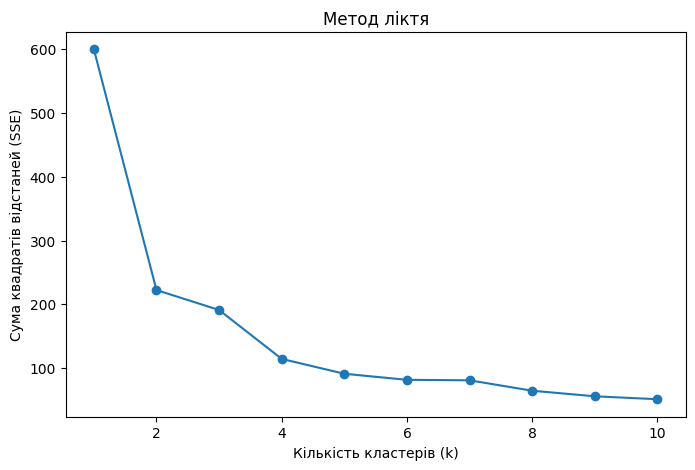

In [4]:
sse = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, sse, marker='o')
plt.xlabel("Кількість кластерів (k)")
plt.ylabel("Сума квадратів відстаней (SSE)")
plt.title("Метод ліктя")
plt.show()

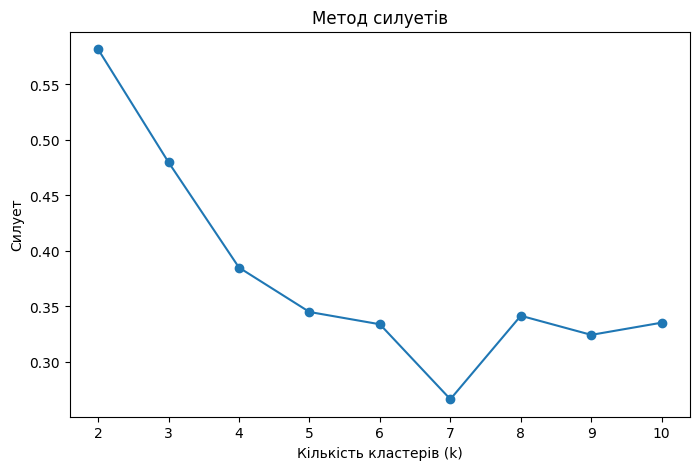

In [5]:
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel("Кількість кластерів (k)")
plt.ylabel("Силует")
plt.title("Метод силуетів")
plt.show()

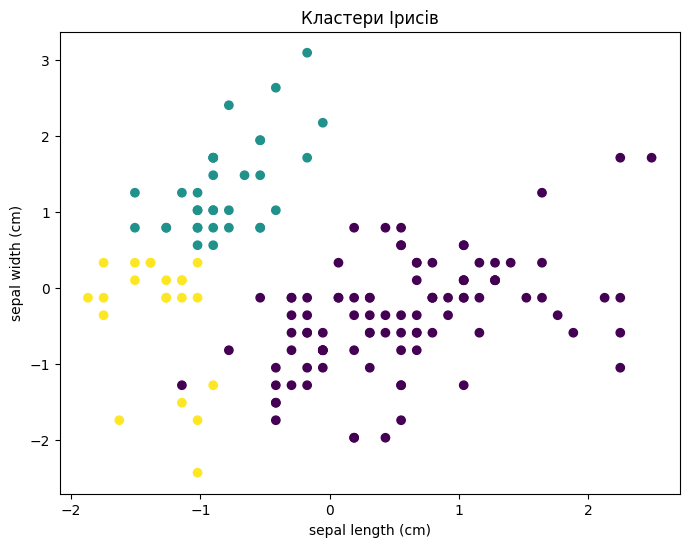

In [6]:
optimal_k = 3  # зазвичай для Ірисів
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

iris_df['Cluster'] = clusters

# Візуалізація кластерів
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap='viridis')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Кластери Ірисів")
plt.show()


In [7]:
print("""
Висновки:
- Метод ліктя та силуетів показав, що оптимальна кількість кластерів – 3.
- Це відповідає трьом видам ірисів у датасеті.
- Кластери добре розділені, особливо за першими двома ознаками.
""")


Висновки:
- Метод ліктя та силуетів показав, що оптимальна кількість кластерів – 3.
- Це відповідає трьом видам ірисів у датасеті.
- Кластери добре розділені, особливо за першими двома ознаками.

